In [117]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression, Ridge, LassoCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor, VotingRegressor



df=pd.read_csv('student_performance_updated_1000.csv')
df.head()

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,1.0,John,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,2.0,Sarah,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,3.0,Alex,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,4.0,Michael,Male,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,5.0,Emma,Female,NaN,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True


In [118]:
df=df.drop(columns=['Name','StudentID','AttendanceRate'])

In [119]:
df=pd.get_dummies(df,columns=['Gender','ParentalSupport','Online Classes Taken'],drop_first=True)

In [120]:
print(df.isnull().sum())

StudyHoursPerWeek            50
PreviousGrade                33
ExtracurricularActivities    43
FinalGrade                   40
Study Hours                  24
Attendance (%)               41
Gender_Male                   0
ParentalSupport_Low           0
ParentalSupport_Medium        0
Online Classes Taken_True     0
dtype: int64


In [121]:
df.dtypes

StudyHoursPerWeek            float64
PreviousGrade                float64
ExtracurricularActivities    float64
FinalGrade                   float64
Study Hours                  float64
Attendance (%)               float64
Gender_Male                     bool
ParentalSupport_Low             bool
ParentalSupport_Medium          bool
Online Classes Taken_True       bool
dtype: object

In [122]:
df['StudyHoursPerWeek']=df['StudyHoursPerWeek'].fillna(df['StudyHoursPerWeek'].mean())
df['Attendance (%)']=df['Attendance (%)'].fillna(df['Attendance (%)'].mean())
df['ExtracurricularActivities']=df['ExtracurricularActivities'].fillna(df['ExtracurricularActivities'].mean())
df['FinalGrade']=df['FinalGrade'].fillna(df['FinalGrade'].mean())
df['Study Hours']=df['Study Hours'].fillna(df['Study Hours'].mean())
df['PreviousGrade']=df['PreviousGrade'].fillna(df['PreviousGrade'].median())

In [123]:
print(df.isnull().sum())

StudyHoursPerWeek            0
PreviousGrade                0
ExtracurricularActivities    0
FinalGrade                   0
Study Hours                  0
Attendance (%)               0
Gender_Male                  0
ParentalSupport_Low          0
ParentalSupport_Medium       0
Online Classes Taken_True    0
dtype: int64


In [124]:
df.head()

,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,FinalGrade,Study Hours,Attendance (%),Gender_Male,ParentalSupport_Low,ParentalSupport_Medium,Online Classes Taken_True
0,15.0,78.0,1.0,80.0,4.8,59.0,True,False,False,False
1,20.0,85.0,2.0,87.0,2.2,70.0,False,False,True,True
2,10.0,65.0,0.0,68.0,4.6,92.0,True,True,False,False
3,25.0,90.0,3.0,92.0,2.9,96.0,True,False,False,False
4,18.0,82.0,2.0,85.0,4.1,97.0,False,False,True,True


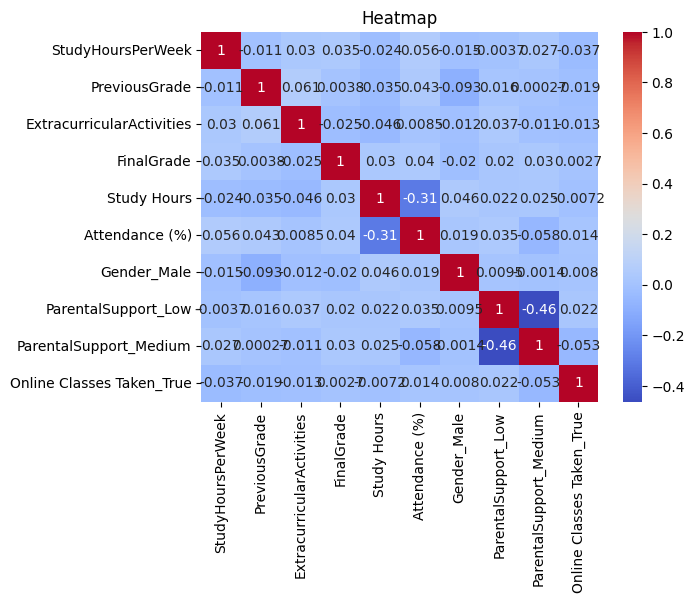

In [125]:
plt.title('Heatmap')
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.show()

In [126]:
X=df.drop(columns=['FinalGrade'])
y=df['FinalGrade']

In [127]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)

ss=StandardScaler()
X_train=ss.fit_transform(X_train)
X_test=ss.transform(X_test)

In [128]:
lr=LinearRegression()
lr.fit(X_train,y_train)
y_pred=lr.predict(X_test)
acc=r2_score(y_test,y_pred)
print("R2: ",r2_score(y_test,y_pred))

R2:  -0.00996256934971762


In [129]:
r=Ridge()
r.fit(X_train,y_train)
y_pred2=r.predict(X_test)
acc2=r2_score(y_test,y_pred2)
print("R2: ",r2_score(y_test,y_pred2))

R2:  -0.00993982175896857


In [130]:
las=LassoCV()
las.fit(X_train,y_train)
y_pred3=las.predict(X_test)
acc3=r2_score(y_test,y_pred3)
print("R2: ",r2_score(y_test,y_pred3))

R2:  -2.0066139039265352e-07


In [131]:
xgbr=XGBRegressor()
xgbr.fit(X_train,y_train)
y_pred4=xgbr.predict(X_test)
acc4=r2_score(y_test,y_pred4)
print("R2: ",r2_score(y_test,y_pred4))

R2:  -0.3048137958670647


In [132]:
rfr=RandomForestRegressor()
rfr.fit(X_train,y_train)
y_pred5=rfr.predict(X_test)
acc5=r2_score(y_test,y_pred5)
print("R2: ",r2_score(y_test,y_pred5))

R2:  -0.054458904610242165


In [133]:
ensemble_mod=VotingRegressor(estimators=[('xgb',xgbr),('rf',rfr)])
ensemble_mod.fit(X_train,y_train)
y_pred6=ensemble_mod.predict(X_test)
acc6=r2_score(y_test,y_pred6)
print("R2: ",r2_score(y_test,y_pred6))            

R2:  -0.11699441475614969


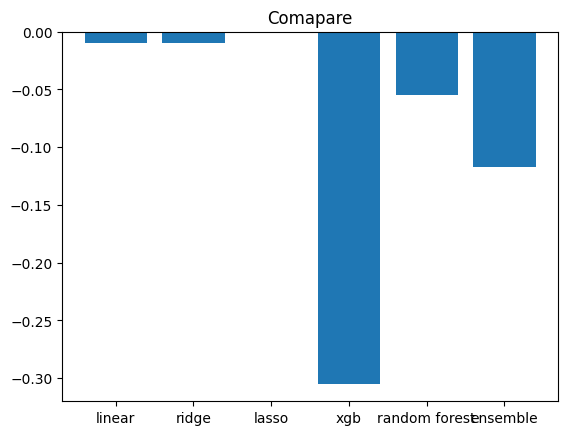

In [135]:
plt.title('Comapare')
accus=[acc,acc2,acc3,acc4,acc5,acc6]
models=['linear','ridge','lasso','xgb','random forest','ensemble']
plt.bar(models,accus)
plt.show()